## Etapa 3 - Análise Exploratória dos Dados (EDA)

1 - Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# sns.set_theme(style="whitegrid", palette="pastel")
sns.set_theme(style="ticks")

DATA_PATH = "../data/raw/desafio_nps_fase_1.csv"


2. Carregamento dos dados

A base de dados utilizada neste projeto está localizada na pasta `data/raw/`, sendo carregada por meio de caminhos relativos para garantir reprodutibilidade do projeto.

In [2]:
df = pd.read_csv(DATA_PATH)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


3. Visão geral dos dados

In [3]:
# Visão geral dos dados
df.info() # resumo do dataframe
df.describe() # resumo estatístico das colunas númericas de um dataframe

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [4]:
# Total de registros na base
num_linhas = df.shape[0]
print(f"O DataFrame tem {num_linhas} linhas")

O DataFrame tem 2500 linhas


In [5]:
# Verificar nulos
df.isnull().sum().sort_values(ascending=False)

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

# Insight
A base apresenta informações completas sobre pedidos, logística e atendimento, permitindo analisar diferentes dimensões da experiência do cliente.

4. Criação da variável de categoria NPS

In [6]:
def categorizar_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["nps_category"] = df["nps_score"].apply(categorizar_nps)

In [7]:
df["nps_category"].unique()

<StringArray>
['Neutro', 'Detrator', 'Promotor']
Length: 3, dtype: str

In [8]:
# Paleta de cores para cada categoria nos gráficos
palette = {
    "Detrator": "#d9534f",   # vermelho
    "Neutro": "#f0ad4e",     # amarelo
    "Promotor": "#5cb85c"    # verde
}

# Define o tamanho da figura
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

5. Distribuição de NPS

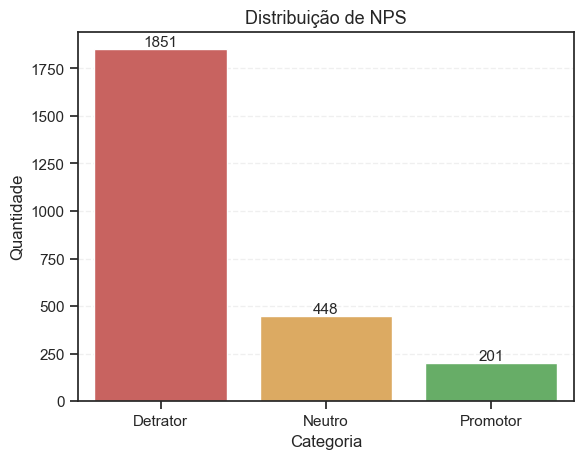

In [9]:
ax = sns.countplot(
    data=df,
    x="nps_category",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

# Adicionando os valores nas barras
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.3),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribuição de NPS", fontsize=13)
plt.xlabel("Categoria")
plt.ylabel("Quantidade")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [10]:
# Calcular a proporção (percentual) de cada categoria de NPS:
(df["nps_category"].value_counts(normalize=True) * 100).round(2)

nps_category
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64

## Interpretação da Distribuição do NPS

Observa-se predominância de clientes detratores na base analisada, indicando um cenário crítico de insatisfação, bem como que a experiência atual apresenta oportunidades relevantes de melhoria operacional.

6. Possíveis fatores críticos

6.1 LOGÍSTICA

## Impacto do atraso logístico na satisfação

O gráfico abaixo compara o atraso médio na entrega entre clientes detratores, neutros e promotores.

O objetivo é verificar se a logística aparece como fator relevante para a satisfação do cliente.

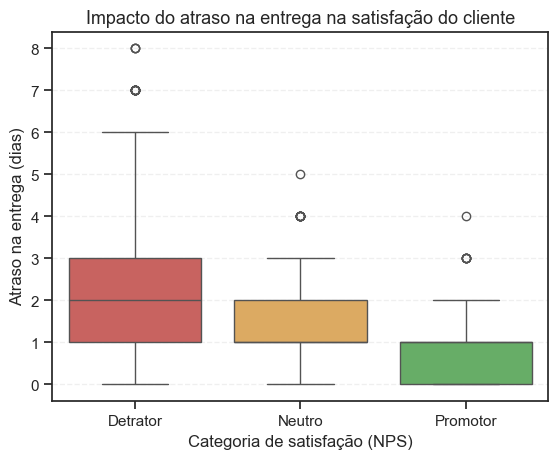

In [11]:
# Atraso vs NPS
sns.boxplot(
    data=df,
    x="nps_category",
    y="delivery_delay_days",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Impacto do atraso na entrega na satisfação do cliente", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Atraso na entrega (dias)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [12]:
# Calcular o atraso médio de entrega para cada categoria de NPS
df.groupby("nps_category")["delivery_delay_days"].mean()

nps_category
Detrator    2.534306
Neutro      1.395089
Promotor    0.756219
Name: delivery_delay_days, dtype: float64

## Insight - Atraso logístico como principal fator de insatisfação

Observa-se que clientes detratores apresentam maior atraso médio na entrega quando comparados a neutros e promotores.

Esse resultado indica que o atraso logístico é um dos principais fatores associados à insatisfação do cliente e deve ser tratado como prioridade operacional.

**Implicação prática:**

Pedidos com risco de atraso devem ser monitorados preventivamente, pois representam maior probabilidade de gerar avaliações negativas.

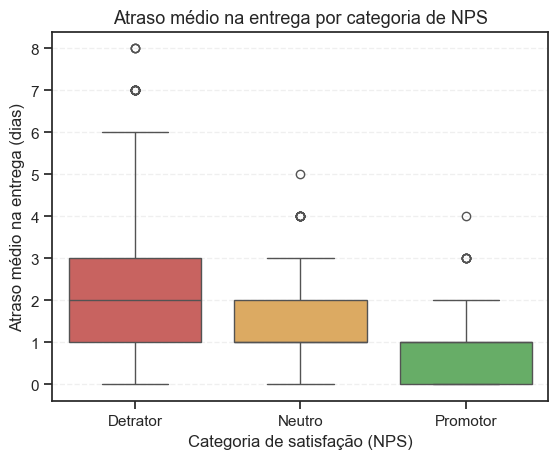

In [13]:
# Gráfico: média de atraso por categoria de NPS
sns.boxplot(
    data=df,
    x="nps_category",
    y="delivery_delay_days",
    hue="nps_category",             # necessário nas versões recentes
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Atraso médio na entrega por categoria de NPS", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Atraso médio na entrega (dias)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

6.2 ATENDIMENTO

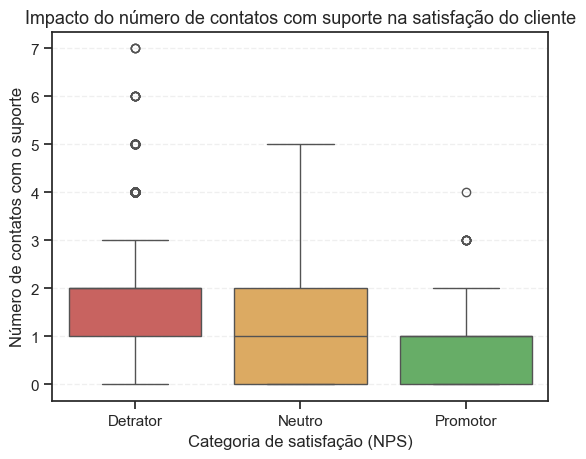

In [14]:
# Contatos com suporte
sns.boxplot(
    data=df,
    x="nps_category",
    y="customer_service_contacts",
    hue="nps_category",             # necessário nas versões recentes
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Impacto do número de contatos com suporte na satisfação do cliente", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Número de contatos com o suporte")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [15]:
# Calcula o número médio de contatos com o suporte por categoria de NPS.
df.groupby("nps_category")["customer_service_contacts"].mean()

nps_category
Detrator    1.694219
Neutro      1.129464
Promotor    0.781095
Name: customer_service_contacts, dtype: float64

## Insight - Contatos com atendimento como indicador de fricção na jornada

Quanto maior o número de contatos com atendimento, menor tende a ser o nível de satisfação do cliente.

Isso indica que o atendimento funciona como sinal de fricção na jornada.

**Contatos com atendimento como indicador de fricção na jornada**

Observou-se que o número médio de contatos com atendimento aumenta entre clientes detratores.

Esse comportamento indica que o atendimento funciona como reflexo de problemas anteriores na experiência do cliente, e não apenas como etapa isolada da jornada.

**Implicação prática:**

Clientes com múltiplos contatos devem ser considerados como grupo prioritário para atuação preventiva.

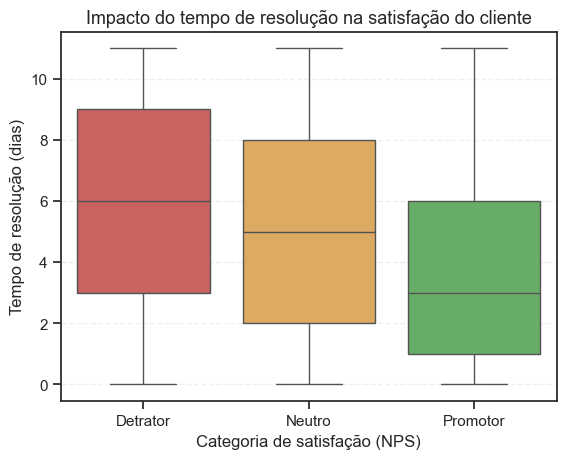

In [16]:
# Tempo de resolução
sns.boxplot(
    data=df,
    x="nps_category",
    y="resolution_time_days",
    hue="nps_category",             # necessário nas versões recentes do Seaborn
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Impacto do tempo de resolução na satisfação do cliente", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Tempo de resolução (dias)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [17]:
# Calcular o tempo médio de resolução por categoria de NPS.
df.groupby("nps_category")["resolution_time_days"].mean()

nps_category
Detrator    5.793625
Neutro      4.832589
Promotor    4.104478
Name: resolution_time_days, dtype: float64

## Insight - Tempo de resolução como amplificador da insatisfação

**Tempo de resolução como amplificador da insatisfação**

Clientes detratores apresentam maior tempo médio de resolução de problemas quando comparados a neutros e promotores.

Esse resultado sugere que a demora na solução de incidentes contribui para deterioração da experiência do cliente.

**Implicação prática:**

Casos com maior tempo de resolução devem ser tratados como eventos críticos da jornada.

6.3 RECLAMAÇÕES DOS CLIENTES

Impacto do número de reclamações na satisfação

Nesta etapa, analisamos a relação entre a quantidade de reclamações registradas e o nível de satisfação do cliente.

O objetivo é verificar se o volume de reclamações funciona como indicador de risco de detratores.

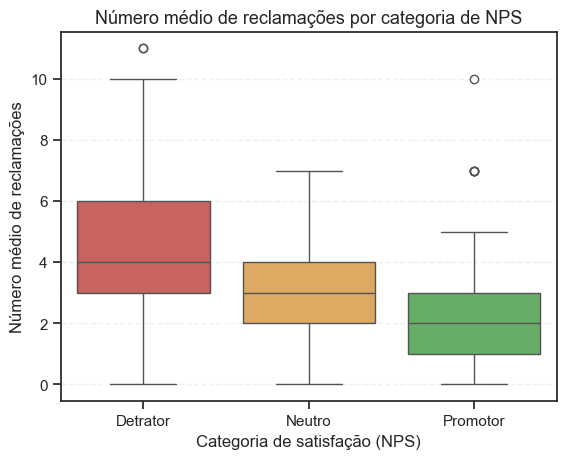

In [18]:
sns.boxplot(
    data=df, 
    x="nps_category", 
    y="complaints_count",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
    )

plt.title("Número médio de reclamações por categoria de NPS", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Número médio de reclamações")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


### Insight - Volume de reclamações como indicador antecipado de detratores

Clientes detratores concentram maior número médio de reclamações. Esse padrão indica que o volume de reclamações pode ser utilizado como sinal antecipado de risco de insatisfação.

Esse resultado reforça que a insatisfação não acontece por um único evento, mas pelo acúmulo de fricções operacionais ao longo da jornada.

**Implicação prática:**

O monitoramento de reclamações permite identificar clientes críticos antes da aplicação da pesquisa de NPS.

6.4 PEDIDO / FINANCEIRO

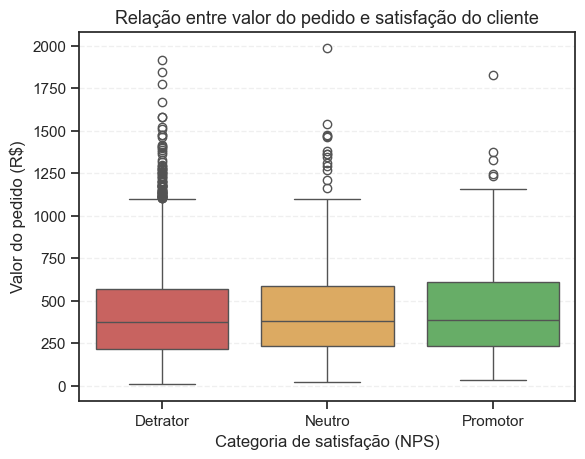

In [19]:
# Valor do pedido
sns.boxplot(
    data=df,
    x="nps_category",
    y="order_value",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Relação entre valor do pedido e satisfação do cliente", fontsize=13)
plt.xlabel("Categoria de satisfação (NPS)")
plt.ylabel("Valor do pedido (R$)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [20]:
# Calcular o valor médio do pedido por categoria de NPS.
df.groupby("nps_category")["order_value"].mean()

nps_category
Detrator    428.985446
Neutro      447.334554
Promotor    453.688607
Name: order_value, dtype: float64

## Insight - Valor do Pedido

O valor do pedido não apresenta relação direta com o NPS, indicando que a experência operacional é mais relevante que o valor gasto com a compra.

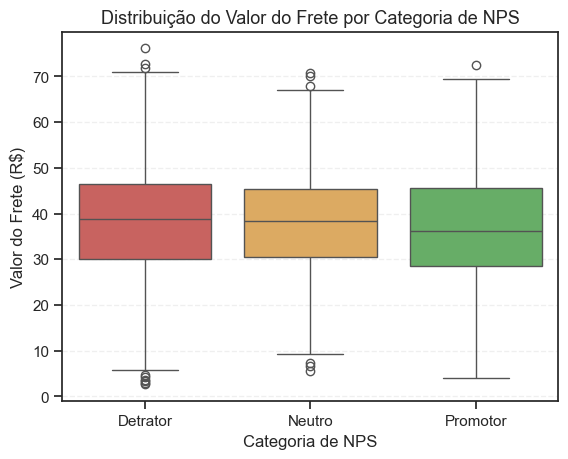

In [21]:
# Frete
sns.boxplot(
    data=df,
    x="nps_category",
    y="freight_value",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Distribuição do Valor do Frete por Categoria de NPS", fontsize=13)
plt.xlabel("Categoria de NPS")
plt.ylabel("Valor do Frete (R$)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [22]:
# Calcular o valor médio do frete por categoria de NPS.
df.groupby("nps_category")["freight_value"].mean()

nps_category
Detrator    38.401091
Neutro      37.908058
Promotor    37.210498
Name: freight_value, dtype: float64

# Insight - Frete

    Observa-se uma leve tendência de clientes detratores apresentam valores médios de frete mais elevados.
    No entanto, a diferença entre os grupos é pequena, sugerindo que o frete pode não ser um fator determinante na satisfação do cliente.

6.5 PERFIL DO CLIENTE

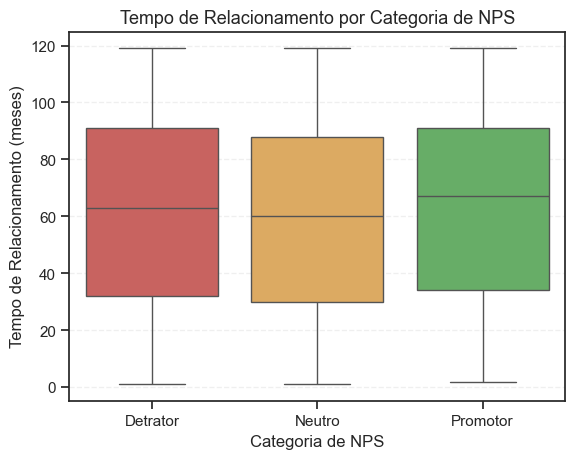

In [23]:
# Tempo de relacionamento
sns.boxplot(
    data=df,
    x="nps_category",
    y="customer_tenure_months",
    hue="nps_category",
    order=["Detrator", "Neutro", "Promotor"],
    palette=palette,
    legend=False
)

plt.title("Tempo de Relacionamento por Categoria de NPS", fontsize=13)
plt.xlabel("Categoria de NPS")
plt.ylabel("Tempo de Relacionamento (meses)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [24]:
# Calcular o tempo médio de relacionamento por categoria de NPS.
df.groupby("nps_category")["customer_tenure_months"].mean()

nps_category
Detrator    61.575365
Neutro      59.506696
Promotor    63.039801
Name: customer_tenure_months, dtype: float64

## Insight - Perfil do Cliente

Observa-se uma leve tendência de clientes com maior tempo de relacionamento apresentarem NPS mais elevado.
No entanto, a diferença entre os grupos é pequena, indicando que o tempo de relacionamento não é um fator determinante isolado para a satisfação do cliente.

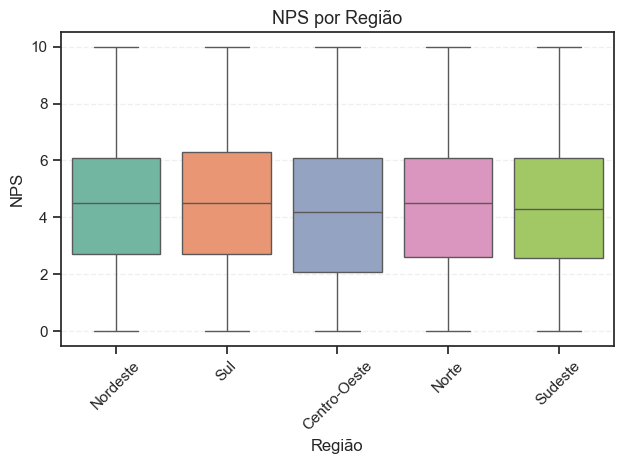

In [25]:
# Região
sns.boxplot(
    data=df,
    x="customer_region",
    y="nps_score",
    hue="customer_region",  # necessário agora
    palette="Set2",
    legend=False
)

plt.title("NPS por Região", fontsize=13)
plt.xlabel("Região")
plt.ylabel("NPS")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Calcular o NPS médio por região
df.groupby("customer_region")["nps_score"].mean().sort_values(ascending=False)

customer_region
Sul             4.490979
Nordeste        4.421649
Norte           4.382609
Sudeste         4.373846
Centro-Oeste    4.209829
Name: nps_score, dtype: float64

7. PONTO DE RUPTURA DA EXPERIÊNCIA DO CLIENTE

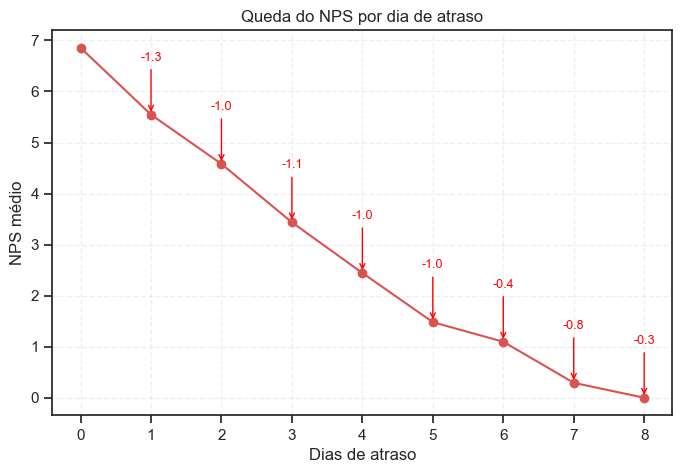

In [27]:
import matplotlib.pyplot as plt
import numpy as np

df_delay = df.groupby("delivery_delay_days")["nps_score"].mean()

plt.figure(figsize=(8,5))
plt.plot(df_delay.index, df_delay.values, marker='o', color="#d9534f")

# Calculando e mostrando a queda diária
for i in range(1, len(df_delay)):
    drop = df_delay.values[i-1] - df_delay.values[i]
    if drop > 0:
        plt.annotate(
            f"-{drop:.1f}", 
            xy=(df_delay.index[i], df_delay.values[i]), 
            xytext=(df_delay.index[i], df_delay.values[i]+1),
            ha='center',
            va='bottom',
            color='red',
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red', lw=1)
        )

plt.xlabel("Dias de atraso")
plt.ylabel("NPS médio")
plt.title("Queda do NPS por dia de atraso")
plt.grid(linestyle='--', alpha=0.3)
plt.show()

## Insight - Ponto de Ruptura da Experiência do Cliente

A maior queda do NPS ocorre já no primeiro dia de atraso, indicando que mesmo pequenos atrasos impactam significativamente a satisfação.
O momento mais crítico da jornada ocorre quando atraso logístico e necessidade de atendimento acontecem juntos.

Nesse cenário aumenta consideravelmente a probabilidade do cliente se tornar detrator.

**Implicação prática:**

Clientes com dupla fricção operacional devem ser priorizados em estratégias preventivas de experiência do cliente.

### Variáveis com menor impacto relativo na satisfação

Variáveis relacionadas ao valor do pedido, valor do frete e características demográficas apresentaram menor impacto na variação do NPS quando comparadas às variáveis operacionais da jornada.

Esse resultado indica que melhorias em logística e atendimento tendem a gerar maior impacto na experiência do cliente do que ajustes financeiros isolados.

8. QUEM SÃO OS DETRATORES

## Perfil dos Clientes Detratores

A análise exploratória permitiu identificar padrões operacionais associados ao comportamento dos clientes detratores.

De forma geral, clientes detratores apresentam maior concentração de fricções ao longo da jornada de compra quando comparados a neutros e promotores.

Os principais fatores associados ao perfil dos detratores foram:

- maior atraso médio na entrega
- maior número de contatos com atendimento
- maior tempo médio de resolução de problemas
- maior volume de reclamações registradas

Esses resultados indicam que a insatisfação não ocorre por um único evento isolado, mas pelo acúmulo de dificuldades operacionais ao longo da experiência do cliente.

### Clientes prioritários para atuação preventiva

Com base nos resultados identificados, recomenda-se priorizar o monitoramento de clientes que apresentem:

- atraso logístico na entrega
- múltiplos contatos com atendimento
- maior tempo de resolução de problemas
- volume elevado de reclamações
- combinação simultânea entre atraso e necessidade de atendimento

Esses grupos apresentam maior probabilidade de se tornarem detratores e devem ser considerados prioritários para intervenções operacionais.

### Aplicação prática da identificação dos detratores

A identificação desses padrões permite que a empresa atue de forma preventiva antes da aplicação da pesquisa de NPS.

Na prática, esses resultados podem ser utilizados para:

- priorizar pedidos com risco de atraso
- identificar clientes com múltiplos contatos como sinal de fricção recorrente
- monitorar tempo de resolução como indicador de experiência crítica
- acompanhar volume de reclamações como alerta antecipado de insatisfação
- direcionar ações preventivas para clientes com maior risco de avaliação negativa

### Tradução do perfil dos detratores em ações operacionais

| Característica observada | Interpretação operacional | Ação recomendada |
|-------------------------|---------------------------|------------------|
| atraso logístico | principal fator de insatisfação | monitoramento preventivo de entregas |
| múltiplos contatos com atendimento | fricção recorrente na jornada | priorização de atendimento |
| tempo elevado de resolução | baixa eficiência na solução | revisão de SLA interno |
| alto volume de reclamações | sinal antecipado de insatisfação | atuação preventiva antes da pesquisa |
| atraso + contato simultâneo | ponto de ruptura da experiência | priorização imediata do cliente |

De forma geral, os resultados indicam que clientes detratores podem ser identificados por sinais operacionais observáveis antes da aplicação da pesquisa de satisfação, permitindo atuação preventiva sobre a experiência do cliente.

## Principais Fatores que Impactam o NPS

Os fatores com maior impacto observado na satisfação foram:

1. atraso logístico
2. número de reclamações
3. contatos com atendimento
4. tempo de resolução

Esses fatores representam as principais oportunidades operacionais para redução de detratores e melhoria da experiência do cliente.

### Tradução dos fatores críticos em ações operacionais

| Fator identificado | Impacto observado | Ação recomendada |
|-------------------|------------------|------------------|
| atraso logístico | principal driver de insatisfação | monitoramento preventivo de entregas |
| contatos com atendimento | sinal de fricção na jornada | priorização de clientes críticos |
| tempo de resolução | amplifica percepção negativa | revisão de SLA interno |
| volume de reclamações | indicador antecipado de detratores | monitoramento preventivo |
| atraso + contato | ponto de ruptura da experiência | atuação imediata |

10. CONSOLIDAÇÃO DOS INSIGHTS

## Principais Insights da Análise Exploratória

A análise exploratória dos dados permitiu identificar padrões relevantes associados ao nível de satisfação do cliente, medido pelo Net Promoter Score (NPS).

Os resultados indicam que a satisfação do cliente está mais relacionada à execução operacional da jornada de compra do que a características financeiras ou demográficas.

**1. O atraso logístico é o principal fator associado à insatisfação**

Clientes detratores apresentam maior atraso médio na entrega quando comparados a neutros e promotores.

Esse resultado indica que a logística representa a principal alavanca de melhoria da experiência do cliente e deve ser tratada como prioridade operacional.

**2. O aumento de contatos com atendimento indica fricção na jornada**

Observou-se que clientes com maior número de contatos com suporte apresentam menor nível de satisfação.

Esse comportamento sugere que o atendimento funciona como indicador de problemas anteriores na experiência do cliente, e não apenas como etapa isolada da jornada.

**3. O tempo de resolução influencia diretamente a percepção da experiência**

Clientes detratores apresentam maior tempo médio de resolução de problemas.

Esse resultado reforça que jornadas com resolução mais lenta ampliam a percepção negativa da experiência e contribuem para a formação de detratores.

**4. O volume de reclamações funciona como indicador antecipado de risco**

Clientes detratores concentram maior número médio de reclamações ao longo da jornada.

Esse padrão sugere que o monitoramento do volume de reclamações pode ser utilizado como indicador preventivo de insatisfação.

**5. Existe um ponto de ruptura claro na experiência do cliente**

A análise combinada entre atraso logístico e necessidade de atendimento evidenciou um ponto crítico da jornada.

Clientes que enfrentam simultaneamente atraso e contato com suporte apresentam os menores níveis médios de NPS.

Esse cenário representa o momento mais sensível da experiência e deve ser priorizado em estratégias de atuação preventiva.

**6. A satisfação está mais associada à execução operacional do que ao valor da compra**

Variáveis relacionadas ao valor do pedido, frete ou características demográficas apresentaram menor impacto na satisfação quando comparadas com variáveis operacionais.

Esse resultado indica que melhorias em logística e atendimento tendem a gerar maior impacto na experiência do cliente.

**7. O NPS apresenta relação direta com recompra**

Observou-se maior taxa de recompra entre clientes com níveis mais altos de satisfação.

Esse resultado reforça o papel do NPS como indicador estratégico de retenção e fidelização no contexto do e-commerce.

### Tradução dos insights em decisões operacionais

| Insight identificado | Ação recomendada |
|---------------------|------------------|
| atraso impacta NPS | melhorar previsibilidade logística |
| múltiplos contatos reduzem satisfação | ampliar comunicação proativa |
| tempo de resolução elevado reduz NPS | reduzir SLA de atendimento |
| alto volume de reclamações indica risco | monitorar clientes críticos |
| atraso + contato é ponto de ruptura | priorizar clientes com dupla fricção |

### Síntese executiva dos fatores críticos

De forma geral, os resultados indicam que atraso logístico, contatos com atendimento, tempo de resolução e volume de reclamações representam os principais fatores associados à insatisfação do cliente.

Esses fatores devem ser priorizados em iniciativas operacionais voltadas à redução de detratores e melhoria da experiência do cliente.

A análise exploratória indicou que a satisfação do cliente está fortemente associada a fatores operacionais da jornada, especialmente atraso logístico, volume de contatos com atendimento, tempo de resolução e número de reclamações.

Com base nesses resultados, recomenda-se priorizar as seguintes ações estratégicas:

**1. Redução de atrasos logísticos**

O atraso na entrega foi identificado como o principal fator associado à insatisfação.

Recomendações:

- monitorar pedidos com risco de atraso antes da entrega
- implementar alertas operacionais preventivos
- melhorar previsibilidade de prazos informados ao cliente
- priorizar pedidos com histórico de atraso recorrente

Impacto esperado:

Redução direta do volume de clientes detratores.

Indicador sugerido:

SLA de entrega no prazo


**2. Comunicação proativa com clientes em risco**

Clientes que enfrentam atraso e precisam acionar atendimento apresentam maior probabilidade de insatisfação.

Recomendações:

- envio automático de notificações em caso de atraso previsto
- comunicação antecipada sobre mudanças de prazo
- transparência no status da entrega

Impacto esperado:

Redução do número de contatos com atendimento e melhora da percepção da experiência.


**3. Redução do número de contatos com atendimento**

O aumento do volume de contatos com suporte foi associado à queda no NPS.

Recomendações:

- ampliar comunicação de status do pedido
- melhorar rastreabilidade da entrega
- disponibilizar canais de autoatendimento eficientes

Impacto esperado:

Redução de fricções na jornada e melhora da satisfação geral.


**4. Redução do tempo de resolução de problemas**

Clientes detratores apresentam maior tempo médio de resolução.

Recomendações:

- priorização automática de chamados críticos
- definição de SLA interno de resolução
- identificação de causas recorrentes de atendimento

Impacto esperado:

Redução da percepção negativa da experiência após incidentes.


**5. Monitoramento do volume de reclamações como indicador de risco**

Clientes detratores apresentam maior número médio de reclamações.

Recomendações:

- utilizar o volume de reclamações como indicador de alerta operacional
- identificar padrões de recorrência de problemas
- atuar preventivamente antes da aplicação da pesquisa de NPS

Impacto esperado:

Antecipação de risco de insatisfação.


**6. Identificação antecipada de clientes com risco de detrator**

A combinação entre atraso logístico e necessidade de atendimento representa um ponto de ruptura na experiência.

Recomendações:

- criação de indicadores operacionais de risco
- priorização de clientes com múltiplas fricções na jornada
- aplicação futura de modelos preditivos de satisfação

Impacto esperado:

Transformação do NPS de indicador reativo para ferramenta preventiva de gestão da experiência do cliente.

## Conclusão e Priorização Operacional

**Clientes que devem ser priorizados**

Com base nos resultados obtidos, recomenda-se priorizar o monitoramento de:

- clientes com atraso logístico identificado
- clientes com múltiplos contatos com atendimento
- clientes com maior tempo de resolução de problemas
- clientes com maior volume de reclamações
- clientes que apresentam simultaneamente atraso e necessidade de atendimento

Esses grupos apresentam maior probabilidade de se tornarem detratores e representam oportunidades de atuação preventiva antes da aplicação da pesquisa de satisfação.

**Ações operacionais recomendadas**

A partir dos fatores críticos identificados, recomenda-se:

Logística:
monitorar pedidos com risco de atraso e ampliar a previsibilidade de entrega

Atendimento:
identificar clientes com múltiplos contatos como sinal de fricção recorrente

Resolução de problemas:
reduzir tempo médio de resolução em casos com histórico de atraso

Reclamações:
utilizar o volume de reclamações como indicador antecipado de risco de detratores

Comunicação com clientes:
implementar comunicação proativa em situações de atraso previsto

**Aplicação prática na operação**

Os resultados desta análise permitem transformar o NPS em um indicador de apoio à tomada de decisão operacional.

Na prática, a empresa pode utilizar esses insights para:

- identificar clientes com risco de insatisfação antes da pesquisa de NPS
- priorizar atendimento para casos com múltiplos contatos registrados
- monitorar atrasos logísticos como principal indicador de risco
- acompanhar o tempo de resolução como métrica de experiência crítica
- utilizar reclamações como sinal de alerta antecipado

Dessa forma, o NPS deixa de atuar apenas como indicador histórico e passa a apoiar decisões preventivas relacionadas à experiência do cliente.

**Priorização das ações com maior impacto esperado**

Com base na análise realizada, recomenda-se a seguinte ordem de prioridade operacional:

Alta prioridade:
redução de atrasos logísticos

Média prioridade:
redução do número de contatos com atendimento

Média prioridade:
redução do tempo de resolução

Prioridade complementar:
monitoramento do volume de reclamações

Essa priorização permite direcionar esforços para os fatores com maior impacto observado na satisfação do cliente.

De forma geral, os resultados indicam que melhorias em logística e atendimento representam as principais alavancas estratégicas para redução de detratores e aumento da satisfação do cliente.